<a href="https://colab.research.google.com/github/ziemniak04/DMS/blob/master/Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge 1: MLPs as Universal Approximators


Write a piece of code and use it to perform numerical experiments that empirically demonstrate that Multi-Layer Perceptrons  can approximate a large class of continuous functions.

# LIBRARIES

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# DATASET SETUP

In [ ]:
# dataset = [(np.array([1,-2]), 0),(np.array([-1,0]), 0),(np.array([2,3]), 1),] # this is an examplary dataset from the class

# large class of functions, so dataset generation using random
dataset = []
elements = 10

while len(dataset) < elements:
    x1 = random.randint(-9, 9) # we define the numbers to be single digit, for the ease of comparison, and computational heaviness
    x2 = random.randint(-9, 9)

    if x2 >= x1 + 1: # points that are >=x1+1 are class 1
        dataset.append((np.array([x1, x2]), 1))
    elif x2 <= x1 - 1:
        dataset.append((np.array([x1, x2]), 0))

random.shuffle(dataset)

for item in dataset[:elements]:
     print(f"x={item[0]}, t={item[1]}")
print("\n")

x=[ 1 -3], t=0
x=[4 8], t=1
x=[-2 -8], t=0
x=[9 7], t=0
x=[ 9 -4], t=0
x=[9 5], t=0
x=[-2 -8], t=0
x=[4 5], t=1
x=[ 3 -5], t=0
x=[5 0], t=0




In [ ]:
# dataset = [(np.array([1,-2]), 0),(np.array([-1,0]), 0),(np.array([2,3]), 1),] # this is an examplary dataset from the class


# PERCEPTRON SETUP

In [ ]:
weight = np.array([0.3,-0.6]) # w is weights for inputs x1 and x2
bias = 1.0 # b is bias
alpha = 0.2 # this is learning rate

# **NON-CONTINUOUS** (HEAVISIDE)

In [ ]:
def heaviside(x):
    return 1 if x >= 0 else 0

step = 0
for epoch in range(1, 100):
    errors = 0
    for x, target in dataset:
        step += 1
        output = heaviside(np.dot(weight, x) + bias) # this is y(t) = f(w(t)*x^(k) + b(t))
        error = target - output
        weight = weight + alpha * error * x
        bias = bias + alpha * error
        print(f"t={step:2d}  x={x}  d={target}  y={output}  e={error:+d}  "
              f"w=[{weight[0]:.1f}, {weight[1]:.1f}]  b={bias:.1f}")
        if error != 0:
            errors += 1
    if errors == 0:
        print(f"\ngot the value after epoch nr: {epoch}.")
        break

t= 1  x=[ 1 -2]  d=0  y=0  e=+0  w=[0.1, 0.6]  b=0.0
t= 2  x=[-1  0]  d=0  y=0  e=+0  w=[0.1, 0.6]  b=0.0
t= 3  x=[2 3]  d=1  y=1  e=+0  w=[0.1, 0.6]  b=0.0

got the value after epoch nr: 1.


## Linear separability (visualization of Heaviside)

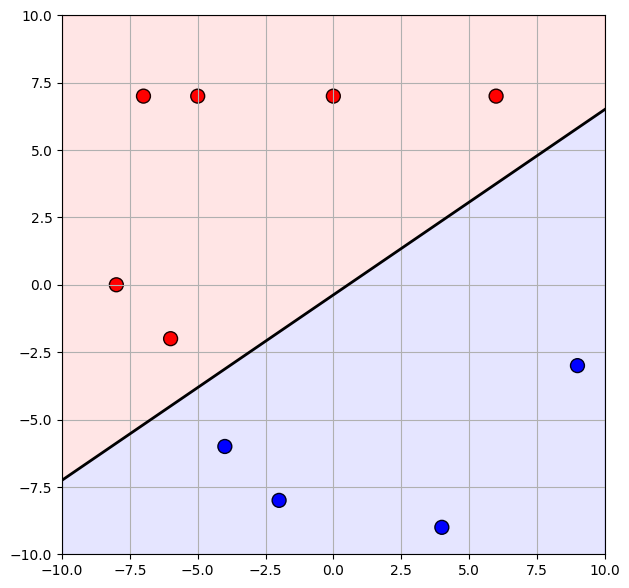

In [ ]:
x_coordinate = [item[0][0] for item in dataset]
y_coordinate = [item[0][1] for item in dataset]
colors = ['red' if item[1] == 1 else 'blue' for item in dataset]

plt.figure(figsize=(7, 7))
plt.scatter(x_coordinate, y_coordinate, c=colors, edgecolors='k', s=100)

# reference line: x2 = -(w1*x1 + b) / w2
x_axis = np.array([-10, 10])
y_axis = -(weight[0] * x_axis + bias) / weight[1]

plt.plot(x_axis, y_axis, color='black', lw=2, label="Granica decyzji")

plt.fill_between(x_axis, y_axis, 10, color='red', alpha =0.1)
plt.fill_between(x_axis, y_axis, -10, color='blue', alpha = 0.1)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.grid(True)
plt.show()

# **CONTINUOUS FUNCTION** (SIGMOID)

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

step = 0
for epoch in range(1, 100):
    errors = 0
    for x, target in dataset:
        step += 1
        # z=(w1​⋅x1​)+(w2​⋅x2​)+bias, weight = w1*x1, x = w2*x2
        weighted_average = np.dot(weight, x) + bias
        output = sigmoid(weighted_average)

        error = target - output

        weight = weight + alpha * error * x
        bias = bias + alpha * error

        prediction = 1 if output >= 0.5 else 0
        if prediction != target:
            errors += 1

        print(f"t={step:2d}  x={x}  d={target}  y={output:.3f}  e={error:+.3f}  "
              f"w=[{weight[0]:.3f}, {weight[1]:.3f}]  b={bias:.3f}")

    if errors == 0:
        print(f"Convergence achieved in epoch: {epoch}")
        break

t= 1  x=[ 9 -8]  d=0  y=0.000  e=-0.000  w=[-1.500, 1.000]  b=0.800
t= 2  x=[-8  0]  d=1  y=1.000  e=+0.000  w=[-1.500, 1.000]  b=0.800
t= 3  x=[8 1]  d=0  y=0.000  e=-0.000  w=[-1.500, 1.000]  b=0.800
t= 4  x=[-1  5]  d=1  y=0.999  e=+0.001  w=[-1.500, 1.001]  b=0.800
t= 5  x=[-6  8]  d=1  y=1.000  e=+0.000  w=[-1.500, 1.001]  b=0.800
t= 6  x=[ 0 -2]  d=0  y=0.231  e=-0.231  w=[-1.500, 1.093]  b=0.754
t= 7  x=[-2  7]  d=1  y=1.000  e=+0.000  w=[-1.500, 1.093]  b=0.754
t= 8  x=[ 3 -3]  d=0  y=0.001  e=-0.001  w=[-1.501, 1.094]  b=0.754
t= 9  x=[-6 -3]  d=1  y=0.998  e=+0.002  w=[-1.503, 1.093]  b=0.754
t=10  x=[-5  1]  d=1  y=1.000  e=+0.000  w=[-1.503, 1.093]  b=0.754
Convergence achieved in epoch: 1


# Linear separability (visualisation of Sigmoid)

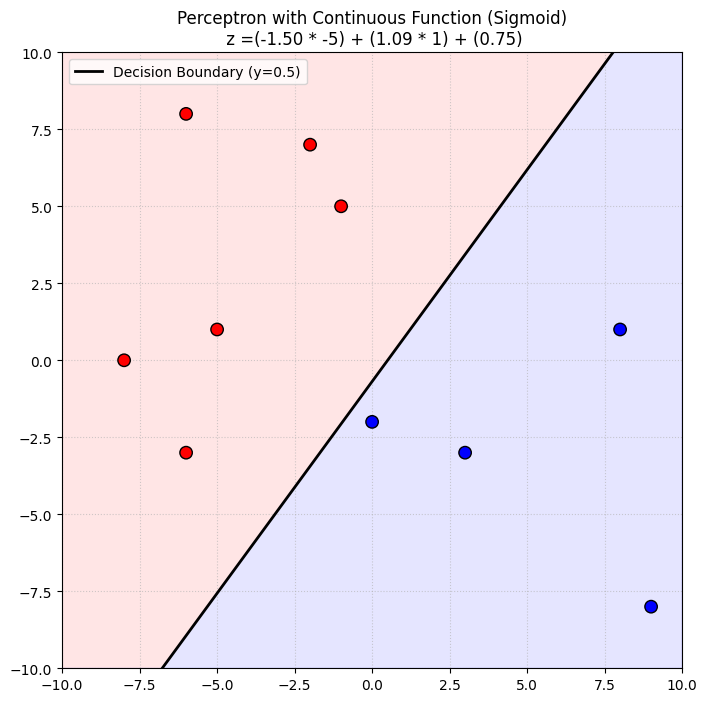

In [ ]:
plt.figure(figsize=(8, 8))

x_coords = [item[0][0] for item in dataset]
y_coords = [item[0][1] for item in dataset]
colors = ['red' if item[1] == 1 else 'blue' for item in dataset]

plt.scatter(x_coords, y_coords, c=colors, edgecolors='k', s=80, zorder=3)

x_axis = np.array([-10, 10])
y_axis = -(weight[0] * x_axis + bias) / weight[1]

plt.plot(x_axis, y_axis, color='black', lw=2, label="Decision Boundary (y=0.5)")

plt.fill_between(x_axis, y_axis, 10, color='red', alpha=0.1)
plt.fill_between(x_axis, y_axis, -10, color='blue', alpha=0.1)

plt.xlim(-10, 10)
plt.ylim(-10, 10)

plt.title(f"Perceptron with Continuous Function (Sigmoid)\n z =({weight[0]:.2f} * {x[0]}) + ({weight[1]:.2f} * {x[1]}) + ({bias:.2f})")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()